# CAPSTONE PROJECT

## Healthcare Management: Patient Readmission Prediction

**Submitted By:** Pragya Raghuwanshi

**Tool Used:** Python (Pandas, NumPy, Matplotlib, Seaborn)

### Project Objective

The objective of this project is to analyze patient healthcare records and identify patterns related to hospital readmissions, diagnoses, treatment utilization, medications, and patient demographics. The analysis aims to provide actionable insights that can support healthcare decision-making and improve patient outcomes.

# Dataset Loading and Initial Exploration

In [1]:
print("Healthcare Management EDA Project")

Healthcare Management EDA Project


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv("diabetic_data_utf8.csv")

In [4]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [5]:
df.shape

(101766, 50)

# Dataset Information

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [18]:
df.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

### Observation

The dataset contains 101,766 patient encounter records and 50 healthcare-related attributes. The dataset includes demographic information, diagnoses, medications, admission details, and readmission status, making it suitable for comprehensive healthcare analytics.

The dataset contains missing values in selected attributes such as weight, payer code, and medical specialty. These missing values are represented using placeholders and should be considered during analysis.

# Task 1: Descriptive Statistical Analysis

In [6]:
numerical_features = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses'
]

df[numerical_features].describe()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


### Observation

The statistical summary provides insights into hospitalization duration, laboratory procedures, medications, and diagnosis counts. The variation across these measures indicates diverse healthcare needs and treatment complexities among patients.

# Task 2: Distribution of Patient Race

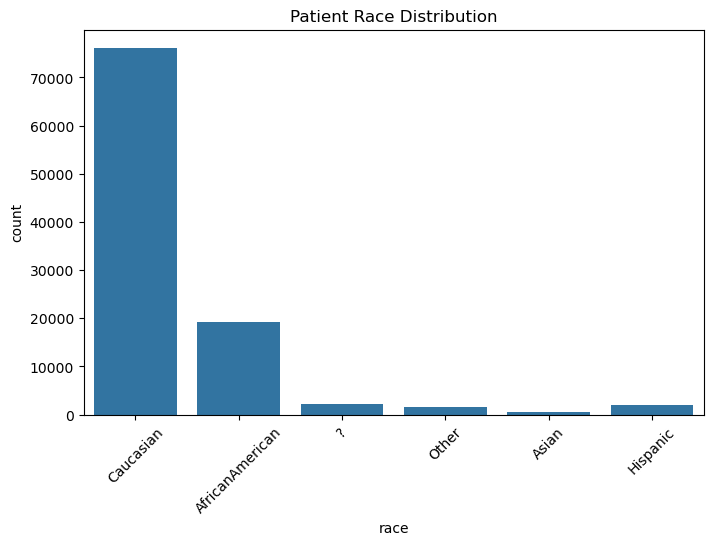

In [7]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='race'
)

plt.xticks(rotation=45)

plt.title('Patient Race Distribution')

plt.show()

### Observation

The majority of patients belong to the Caucasian category, followed by African American patients. Other racial groups represent a comparatively smaller share of the patient population.

# Task 3: Distribution of Patient Gender

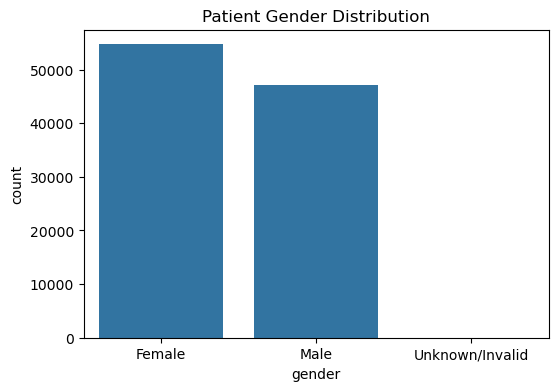

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='gender'
)

plt.title('Patient Gender Distribution')

plt.show()

### Observation

The dataset contains both male and female patients in substantial proportions, enabling balanced demographic analysis across genders.

# Task 4: Relationship Between Readmission Status and Age Group

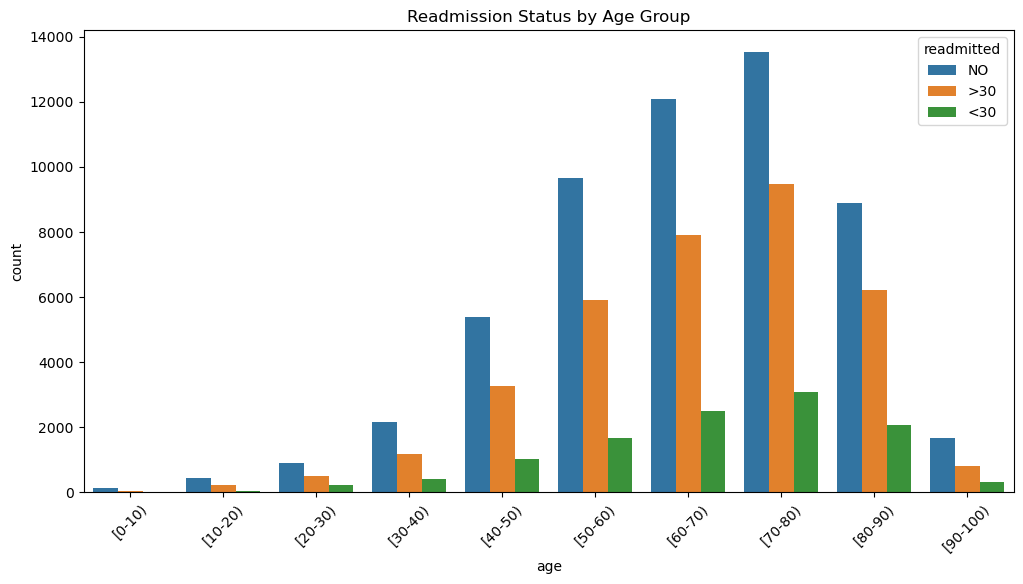

In [9]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x='age',
    hue='readmitted'
)

plt.xticks(rotation=45)

plt.title('Readmission Status by Age Group')

plt.show()

### Observation

Readmission frequency generally increases in older age groups. Elderly patients appear to experience higher rates of hospital readmission compared to younger patients.

# Task 5: Correlation Analysis of Numerical Features

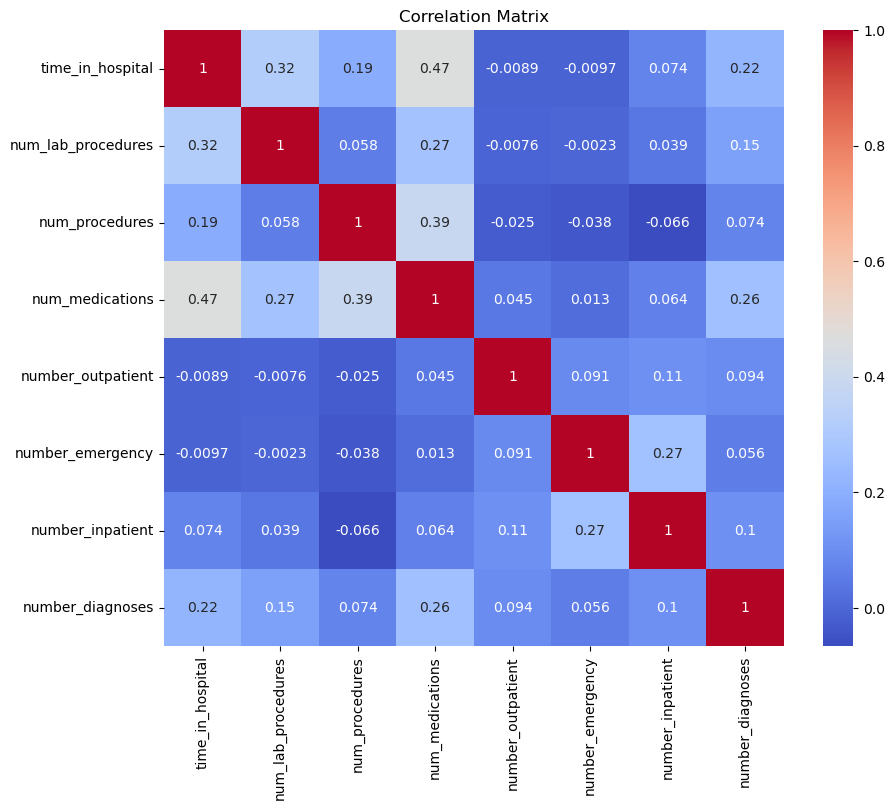

In [10]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df[numerical_features].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()

### Observation

Most numerical variables exhibit weak to moderate correlations, suggesting that patient outcomes are influenced by multiple healthcare factors rather than a single dominant variable.

# Task 6: Analysis of Medication Changes and Total Medications

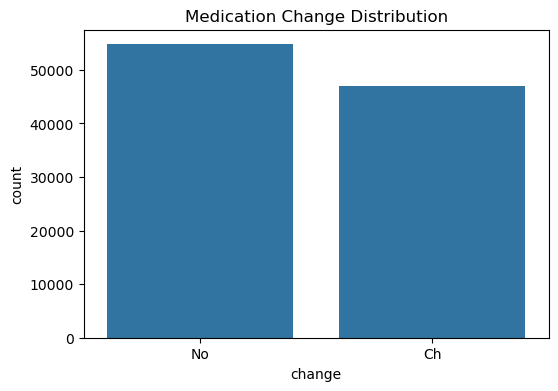

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='change'
)

plt.title('Medication Change Distribution')

plt.show()

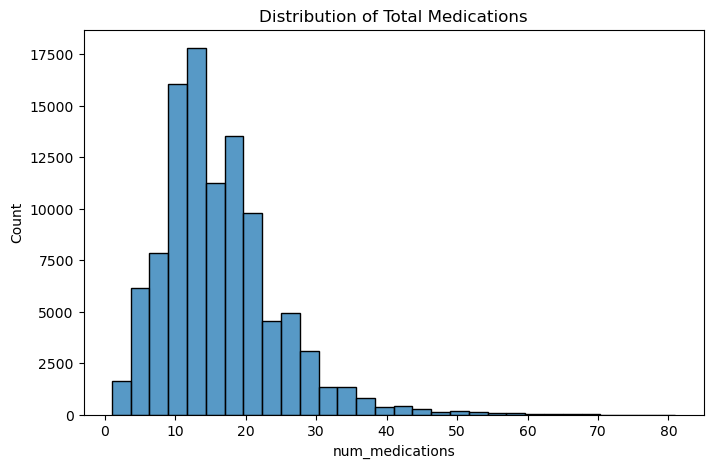

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['num_medications'],
    bins=30
)

plt.title('Distribution of Total Medications')

plt.show()

### Observation

Medication changes are common among patients, and the number of medications prescribed varies significantly across patient encounters, reflecting diverse treatment requirements.

# Task 7: Distribution of Diagnosis Categories

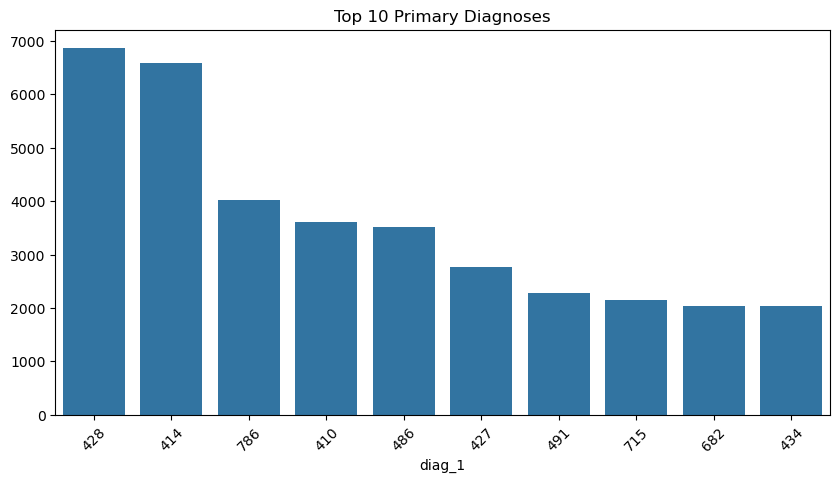

In [13]:
top_diag = df['diag_1'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_diag.index,
    y=top_diag.values
)

plt.title('Top 10 Primary Diagnoses')

plt.xticks(rotation=45)

plt.show()

### Observation

A small number of diagnosis categories account for a large proportion of patient encounters, indicating recurring health conditions within the healthcare system.

# Task 8: Admission Types, Sources and Discharge Dispositions

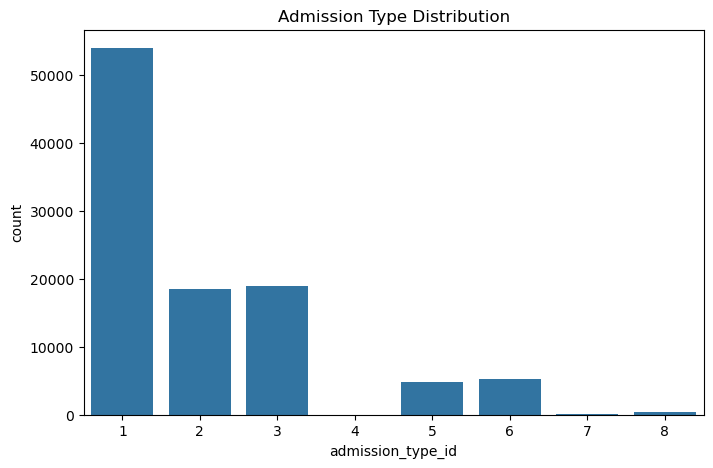

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='admission_type_id'
)

plt.title('Admission Type Distribution')

plt.show()

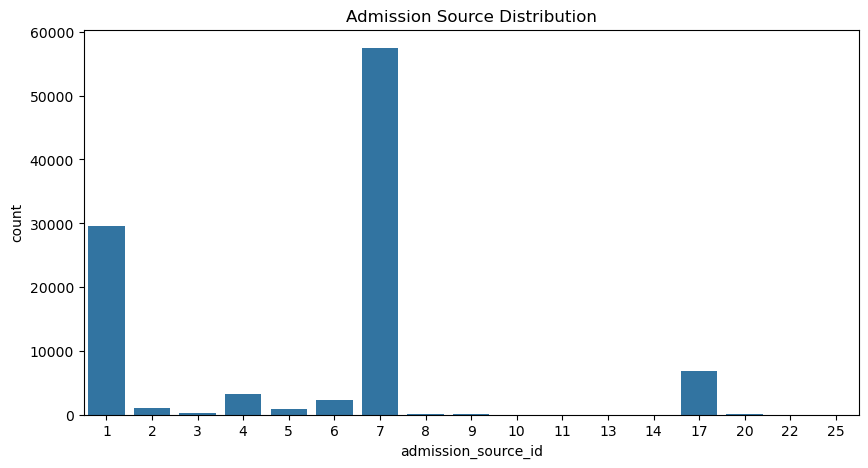

In [15]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='admission_source_id'
)

plt.title('Admission Source Distribution')

plt.show()

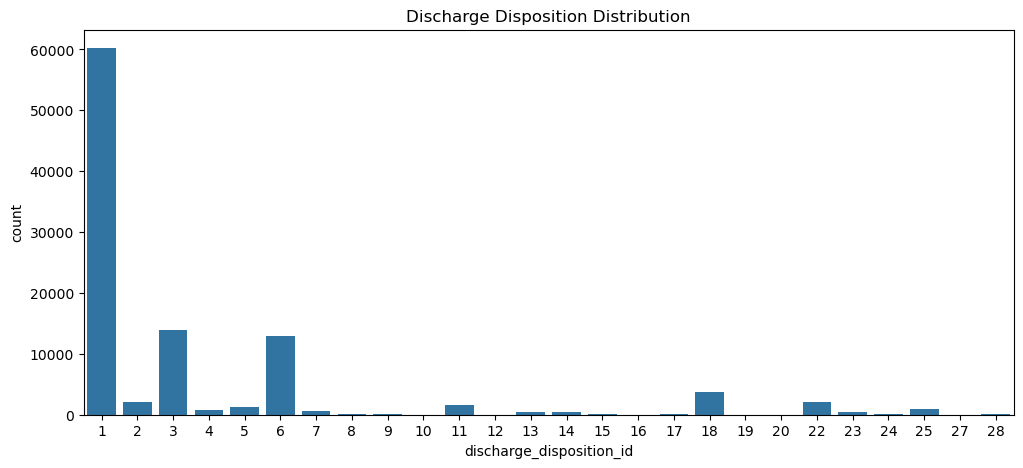

In [16]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x='discharge_disposition_id'
)

plt.title('Discharge Disposition Distribution')

plt.show()

### Observation

The distributions highlight the most common admission pathways, referral sources, and discharge outcomes among patients, providing insights into healthcare service utilization.

# Final Conclusion

The Python-based exploratory data analysis successfully examined patient demographics, diagnoses, hospital utilization patterns, medications, and readmission behavior. The analysis revealed important trends related to age, race, treatment intensity, and healthcare utilization.

These insights can support healthcare professionals in identifying high-risk patient groups, improving discharge planning, optimizing treatment strategies, and reducing hospital readmission rates through data-driven decision-making.